In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
MODEL_PATH = "/content/drive/MyDrive/best_brisc_unet.pth"
IMAGE_PATH = "/content/Screenshot 2026-08-13 193735.png"

# Output files
MASK_OUTPUT_PATH = "segmented_mask.png"
OVERLAY_OUTPUT_PATH = "tumor_overlay.png"


# Image size used during training
IMAGE_SIZE = 256

# Segmentation threshold
THRESHOLD = 0.5

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("Brain Tumor Segmentation")
print("=" * 60)

print("Device:", device)

Brain Tumor Segmentation
Device: cuda


In [6]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.double_conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):

        return self.double_conv(x)

In [7]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1
    ):
        super().__init__()

        # Encoder

        self.enc1 = DoubleConv(
            in_channels,
            64
        )

        self.enc2 = DoubleConv(
            64,
            128
        )

        self.enc3 = DoubleConv(
            128,
            256
        )

        self.enc4 = DoubleConv(
            256,
            512
        )


        # Bottleneck

        self.bottleneck = DoubleConv(
            512,
            1024
        )


        # Pooling

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # Decoder

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )


        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )


        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )


        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )


        # Output layer

        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )


    def forward(self, x):

        # Encoder

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )


        # Bottleneck

        b = self.bottleneck(
            self.pool(e4)
        )


        # Decoder

        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)


        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)


        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)


        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)


        output = self.final(d1)

        return output

In [8]:
print("\nLoading model...")

model = UNet(
    in_channels=3,
    out_channels=1
)


checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)


Loading model...


In [9]:
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        "Checkpoint loaded successfully."
    )

    if "val_dice" in checkpoint:

        print(
            f"Best Validation Dice: "
            f"{checkpoint['val_dice']:.4f}"
        )

else:

    # If only state_dict was saved
    model.load_state_dict(
        checkpoint
    )

    print(
        "Model weights loaded successfully."
    )


Checkpoint loaded successfully.
Best Validation Dice: 0.8514


In [10]:
model = model.to(device)

model.eval()

UNet(
  (enc1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
  

In [24]:
print("\nLoading MRI image...")

if not os.path.exists(IMAGE_PATH):

    raise FileNotFoundError(
        f"\nImage not found:\n{IMAGE_PATH}"
    )


image = cv2.imread(
    IMAGE_PATH
)


if image is None:

    raise ValueError(
        "Unable to read the image."
    )



Loading MRI image...


In [25]:
image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)


print(
    "Original image shape:",
    image.shape
)


# Keep original image for visualization

original_image = image.copy()

Original image shape: (793, 685, 3)


In [26]:
transform = A.Compose([

    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),

    ToTensorV2()

])


transformed = transform(
    image=image
)

In [27]:
input_tensor = transformed[
    "image"
]


# Add batch dimension

input_tensor = input_tensor.unsqueeze(
    0
)


input_tensor = input_tensor.to(
    device
)


print(
    "Input tensor shape:",
    input_tensor.shape
)

Input tensor shape: torch.Size([1, 3, 256, 256])


In [28]:
print("\nRunning segmentation...")

with torch.no_grad():

    output = model(
        input_tensor
    )


# Convert logits → probability

probability = torch.sigmoid(
    output
)


# Convert probability → binary mask

prediction = (
    probability >= THRESHOLD
).float()


# Remove batch/channel dimensions

prediction = (
    prediction[0, 0]
    .cpu()
    .numpy()
)


Running segmentation...


In [29]:
original_height = original_image.shape[0]
original_width = original_image.shape[1]


prediction = cv2.resize(
    prediction.astype(np.uint8),
    (
        original_width,
        original_height
    ),
    interpolation=cv2.INTER_NEAREST
)

In [30]:
tumor_pixels = np.sum(
    prediction == 1
)

total_pixels = prediction.size


tumor_percentage = (
    tumor_pixels /
    total_pixels
) * 100


print("\nSegmentation complete.")

print(
    "Tumor pixels:",
    tumor_pixels
)

print(
    "Total pixels:",
    total_pixels
)

print(
    f"Predicted tumor area: "
    f"{tumor_percentage:.2f}%"
)


Segmentation complete.
Tumor pixels: 41932
Total pixels: 543205
Predicted tumor area: 7.72%


In [31]:
binary_mask = (
    prediction * 255
).astype(np.uint8)


cv2.imwrite(
    MASK_OUTPUT_PATH,
    binary_mask
)


print(
    "\nSegmented mask saved to:"
)

print(
    os.path.abspath(
        MASK_OUTPUT_PATH
    )
)


Segmented mask saved to:
/content/segmented_mask.png


In [32]:
overlay = original_image.copy()


# Create tumor mask

tumor_mask = (
    prediction == 1
)


# Create an overlay image

overlay[tumor_mask] = [
    255,
    0,
    0
]


# Blend original + segmentation

overlay = cv2.addWeighted(
    original_image,
    0.65,
    overlay,
    0.35,
    0
)

In [33]:
cv2.imwrite(
    OVERLAY_OUTPUT_PATH,
    cv2.cvtColor(
        overlay,
        cv2.COLOR_RGB2BGR
    )
)


print(
    "Tumor overlay saved to:"
)

print(
    os.path.abspath(
        OVERLAY_OUTPUT_PATH
    )
)

Tumor overlay saved to:
/content/tumor_overlay.png


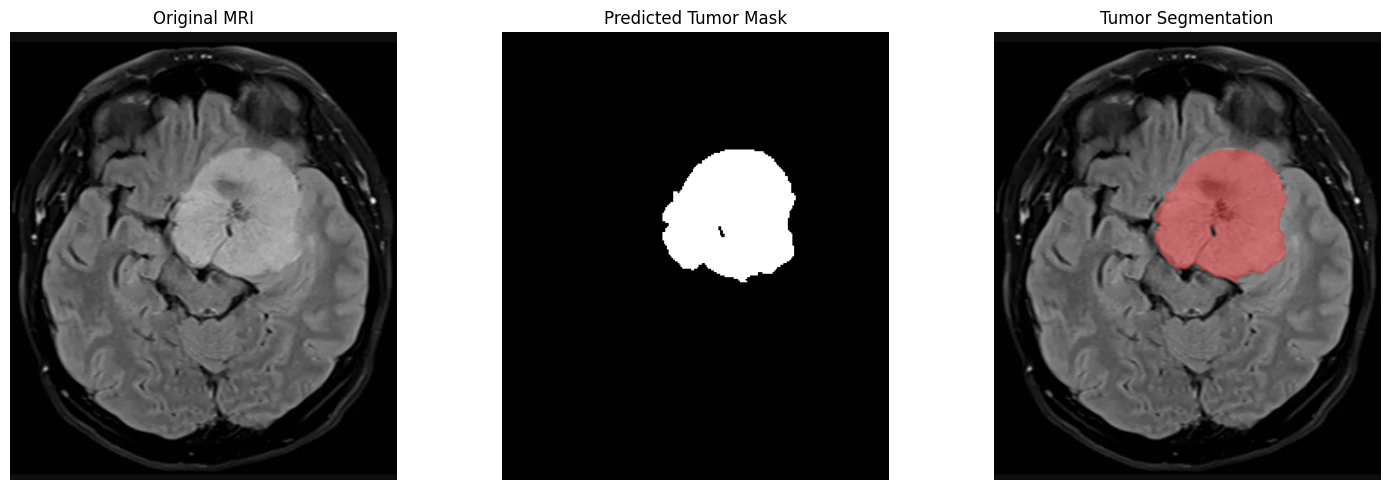


Done!


In [34]:
plt.figure(
    figsize=(15, 5)
)


# Original MRI

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    original_image
)

plt.title(
    "Original MRI"
)

plt.axis(
    "off"
)


# Segmentation mask

plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    prediction,
    cmap="gray"
)

plt.title(
    "Predicted Tumor Mask"
)

plt.axis(
    "off"
)


# Overlay

plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    overlay
)

plt.title(
    "Tumor Segmentation"
)

plt.axis(
    "off"
)


plt.tight_layout()

plt.show()


print("\nDone!")